[English](01_eda.ipynb) · [Español](01_eda_es.ipynb)

# 01 — EDA (working notebook, imports `src/fraud`)

Companion to `src/fraud/data.py`: uses the same loader and the same split as the
production package, so any number seen here is the same one the training pipeline
sees. The full narrative is in `fraud-portfolio.ipynb`; this notebook is for
exploring while `src/` is being modified.


In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "fraud").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from src.fraud.data import make_split


In [2]:
split = make_split(PROJECT_ROOT / "data/raw/fraudTrain.csv", PROJECT_ROOT / "data/raw/fraudTest.csv")
for name, frame in [("train", split.train), ("valid", split.valid), ("test", split.test)]:
    print(f"{name:5s} rows={len(frame):>9,}  fraud={frame['is_fraud'].sum():>6,}  "
          f"prevalence={frame['is_fraud'].mean():.4%}  cards={frame['cc_num'].nunique()}")


train rows=1,037,340  fraud= 5,968  prevalence=0.5753%  cards=964
valid rows=  259,335  fraud= 1,538  prevalence=0.5931%  cards=927
test  rows=  555,719  fraud= 2,145  prevalence=0.3860%  cards=924


`train`/`valid` come from cutting `fraudTrain.csv` by date; `test` is `fraudTest.csv`
untouched. Prevalence drops from train to test -- that's real drift between periods,
not a split error.


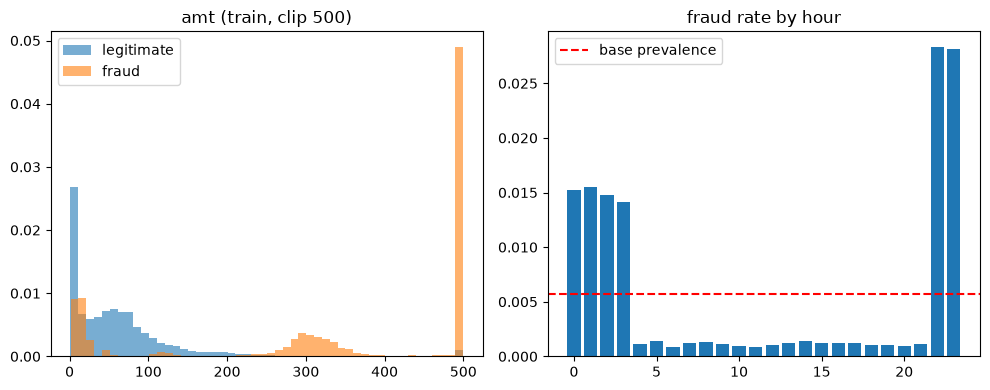

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for is_fraud, label in [(0, "legitimate"), (1, "fraud")]:
    ax[0].hist(split.train.loc[split.train["is_fraud"] == is_fraud, "amt"].clip(upper=500),
               bins=50, alpha=0.6, density=True, label=label)
ax[0].set_title("amt (train, clip 500)")
ax[0].legend()

hour_rate = split.train.groupby(split.train["trans_date_trans_time"].dt.hour)["is_fraud"].mean()
ax[1].bar(hour_rate.index, hour_rate.values)
ax[1].axhline(split.train["is_fraud"].mean(), color="red", linestyle="--", label="base prevalence")
ax[1].set_title("fraud rate by hour")
ax[1].legend()
plt.tight_layout()
plt.show()


`amt` separates the two classes (fraud concentrates higher amounts). The fraud rate
by hour shows the night peak used for `is_night` in `src/fraud/features.py`. Same
result as the root notebook, computed here with the production loader instead of
plain `pd.read_csv`.
